In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, WeightedRandomSampler

torch.random.seed = 0
np.random.seed(0)

In [3]:
from datasets import *
from tokenizer import LogTokenizer
from utils import get_padded_data
from model.loss_function import SimpleLossCompute
from model.model import LogsyModel
from model.trainer import run_train, run_test

In [4]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score

# Auxiliary Datasets

### BGL Dataset

In [5]:
aux_size = 300000
bgl_dataset = BGLDataset(aux=True, aux_size=aux_size)

### Spirit2 Dataset

In [6]:
every_n = 100
aux_size = 100000
spirit_dataset = SpiritDataset(every_n=every_n, aux_size=aux_size,aux=True)

### Intrepid_RAS_0901_0908_scrubbed Dataset

In [7]:
intrepid_dataset = InterpidScrubbedDataset(aux=True)

### Thunderbird Dataset

In [8]:
max_lines = 5000000
tbird_dataset = ThunderbirdDataset(max_lines=max_lines)

### Model params

In [9]:
dataset = tbird_dataset
aux_datasets = [bgl_dataset, spirit_dataset, intrepid_dataset]

model_params = {
    "tgt_vocab":2,
    "n_layers":2,
    "in_features":16,
    "out_features":16,
    "num_heads":2,
    "dropout":0.05,
    "max_len":50
    
}

split_size =0.8
batch_size=2048
pad_len=50
loss_criterion = nn.CrossEntropyLoss(weight=torch.tensor([0.3,1.0]).cuda())#
model_path='../output/models/'
epochs=30


In [10]:
from logsy import LogsyRunner

In [11]:
logsy_run = LogsyRunner(dataset=dataset,
                       aux_datasets=aux_datasets,
                       model_params=model_params,
                       split_size=split_size,
                       batch_size=batch_size,
                       pad_len=pad_len,
                       loss_criterion=loss_criterion,
                       model_path=model_path,
                       epochs=epochs)

In [15]:
load, labels = logsy_run.init_data(dataset, aux_datasets)

In [16]:
log_payload = logsy_run.tokenize_data(load)


100%|██████████| 5425499/5425499 [01:17<00:00, 69732.21it/s] 


In [17]:
data_token_indexed = log_payload
true_labels = labels

In [18]:
load_train, labels_train, load_test, labels_test = logsy_run.train_test_split(log_payload, labels.flatten())


In [19]:
train_dataloader, test_dataloader = logsy_run.create_data_loaders(load_train, labels_train, load_test,
                                                             labels_test)

In [20]:
torch.cuda.set_device(0)

In [21]:
torch.cuda.set_device(0)

logsy_run.run_optimizer(train_dataloader, test_dataloader)


Epoch 0
Epoch Step: 1 / 2082 Loss: 3.464210
Epoch Step: 101 / 2082 Loss: 3.429272
Epoch Step: 201 / 2082 Loss: 3.320813
Epoch Step: 301 / 2082 Loss: 3.235980
Epoch Step: 401 / 2082 Loss: 3.182950
Epoch Step: 501 / 2082 Loss: 3.031007
Epoch Step: 601 / 2082 Loss: 2.997374
Epoch Step: 701 / 2082 Loss: 2.949086
Epoch Step: 801 / 2082 Loss: 2.831513
Epoch Step: 901 / 2082 Loss: 2.788023
Epoch Step: 1001 / 2082 Loss: 2.717461
Epoch Step: 1101 / 2082 Loss: 2.688769
Epoch Step: 1201 / 2082 Loss: 2.612612


KeyboardInterrupt: 

# Create model

In [18]:
model_params = {
    "tgt_vocab":2
    "n_layers":2,
    "in_features":16,
    "out_features":16,
    "num_heads":2,
    "dropout":0.05,
    "max_len":50
    
}

### Initialize loss and optimizer

In [83]:
#loss
criterion = 
model_opt = 

In [84]:
max_auc = 0.0
max_distances = 0
for epoch in range(30):
    model.train()
    print("Epoch",epoch)
    run_train(train_dataloader, model, 
             SimpleLossCompute(model, criterion, model_opt), step_size=100)
    torch.save(model.state_dict(), '../output/models/model_'+str(epoch)+'.pt')
    
    
    #test
    model.eval()
    preds, distances = run_test(test_dataloader, model, 
                        SimpleLossCompute(model, criterion, None, is_test=True), step_size=100)

    preds = np.array(preds)
    auc = roc_auc_score(test_ground_labels.astype(np.int32), distances)
    print("AUC:", auc)
    if auc > max_auc:
        max_auc = auc
        fpr, tpr, thresholds = roc_curve(test_ground_labels.astype(np.int32), distances, pos_label=1)
        np.save(str(aux_size)+'_without8020.npy',[fpr, tpr, thresholds])
        print(roc_auc_score(test_ground_labels.astype(np.int32), distances))
        max_distances = distances
    

Epoch 0
Epoch Step: 1 / 2180 Loss: 3.268634
Epoch Step: 101 / 2180 Loss: 3.249446
Epoch Step: 201 / 2180 Loss: 3.177441
Epoch Step: 301 / 2180 Loss: 3.124229
Epoch Step: 401 / 2180 Loss: 3.000609
Epoch Step: 501 / 2180 Loss: 2.933898
Epoch Step: 601 / 2180 Loss: 2.884660
Epoch Step: 701 / 2180 Loss: 2.802370
Epoch Step: 801 / 2180 Loss: 2.680750
Epoch Step: 901 / 2180 Loss: 2.595043
Epoch Step: 1001 / 2180 Loss: 2.558646
Epoch Step: 1101 / 2180 Loss: 2.476412
Epoch Step: 1201 / 2180 Loss: 2.447673
Epoch Step: 1301 / 2180 Loss: 2.271137
Epoch Step: 1401 / 2180 Loss: 2.286556
Epoch Step: 1501 / 2180 Loss: 2.217210
Epoch Step: 1601 / 2180 Loss: 2.181738
Epoch Step: 1701 / 2180 Loss: 2.087662
Epoch Step: 1801 / 2180 Loss: 1.999464
Epoch Step: 1901 / 2180 Loss: 1.954398
Epoch Step: 2001 / 2180 Loss: 1.929347
Epoch Step: 2101 / 2180 Loss: 1.886674
Epoch Step: 1 / 488 Loss: 1.979331
Epoch Step: 101 / 488 Loss: 2.060996
Epoch Step: 201 / 488 Loss: 1.992939
Epoch Step: 301 / 488 Loss: 2.008496


Epoch Step: 1901 / 2180 Loss: 0.007730
Epoch Step: 2001 / 2180 Loss: 0.008701
Epoch Step: 2101 / 2180 Loss: 0.007131
Epoch Step: 1 / 488 Loss: 0.283096
Epoch Step: 101 / 488 Loss: 0.118327
Epoch Step: 201 / 488 Loss: 0.255676
Epoch Step: 301 / 488 Loss: 0.224315
Epoch Step: 401 / 488 Loss: 0.330150
AUC: 0.9997113872090431
Epoch 8
Epoch Step: 1 / 2180 Loss: 0.007655
Epoch Step: 101 / 2180 Loss: 0.010531
Epoch Step: 201 / 2180 Loss: 0.009500
Epoch Step: 301 / 2180 Loss: 0.007715
Epoch Step: 401 / 2180 Loss: 0.007679
Epoch Step: 501 / 2180 Loss: 0.008610
Epoch Step: 601 / 2180 Loss: 0.011940
Epoch Step: 701 / 2180 Loss: 0.009887
Epoch Step: 801 / 2180 Loss: 0.008559
Epoch Step: 901 / 2180 Loss: 0.006972
Epoch Step: 1001 / 2180 Loss: 0.008118
Epoch Step: 1101 / 2180 Loss: 0.006890
Epoch Step: 1201 / 2180 Loss: 0.006946
Epoch Step: 1301 / 2180 Loss: 0.009574
Epoch Step: 1401 / 2180 Loss: 0.007019
Epoch Step: 1501 / 2180 Loss: 0.008086
Epoch Step: 1601 / 2180 Loss: 0.007504
Epoch Step: 1701 

Epoch Step: 1201 / 2180 Loss: 0.005984
Epoch Step: 1301 / 2180 Loss: 0.005948
Epoch Step: 1401 / 2180 Loss: 0.007508
Epoch Step: 1501 / 2180 Loss: 0.006114
Epoch Step: 1601 / 2180 Loss: 0.009528
Epoch Step: 1701 / 2180 Loss: 0.009920
Epoch Step: 1801 / 2180 Loss: 0.008052
Epoch Step: 1901 / 2180 Loss: 0.006103
Epoch Step: 2001 / 2180 Loss: 0.007738
Epoch Step: 2101 / 2180 Loss: 0.007174
Epoch Step: 1 / 488 Loss: 0.395047
Epoch Step: 101 / 488 Loss: 0.165051
Epoch Step: 201 / 488 Loss: 0.356741
Epoch Step: 301 / 488 Loss: 0.312957
Epoch Step: 401 / 488 Loss: 0.460772
AUC: 0.99904010436907
Epoch 16
Epoch Step: 1 / 2180 Loss: 0.007814
Epoch Step: 101 / 2180 Loss: 0.007309
Epoch Step: 201 / 2180 Loss: 0.007339
Epoch Step: 301 / 2180 Loss: 0.006150
Epoch Step: 401 / 2180 Loss: 0.007321
Epoch Step: 501 / 2180 Loss: 0.006404
Epoch Step: 601 / 2180 Loss: 0.006799
Epoch Step: 701 / 2180 Loss: 0.007385
Epoch Step: 801 / 2180 Loss: 0.007308
Epoch Step: 901 / 2180 Loss: 0.005521
Epoch Step: 1001 /

Epoch Step: 501 / 2180 Loss: 0.005988
Epoch Step: 601 / 2180 Loss: 0.005338
Epoch Step: 701 / 2180 Loss: 0.005246
Epoch Step: 801 / 2180 Loss: 0.006205
Epoch Step: 901 / 2180 Loss: 0.006014
Epoch Step: 1001 / 2180 Loss: 0.006494
Epoch Step: 1101 / 2180 Loss: 0.005046
Epoch Step: 1201 / 2180 Loss: 0.007530
Epoch Step: 1301 / 2180 Loss: 0.004703
Epoch Step: 1401 / 2180 Loss: 0.006042
Epoch Step: 1501 / 2180 Loss: 0.008894
Epoch Step: 1601 / 2180 Loss: 0.006040
Epoch Step: 1701 / 2180 Loss: 0.006998
Epoch Step: 1801 / 2180 Loss: 0.004327
Epoch Step: 1901 / 2180 Loss: 0.006732
Epoch Step: 2001 / 2180 Loss: 0.005724
Epoch Step: 2101 / 2180 Loss: 0.008655
Epoch Step: 1 / 488 Loss: 0.443381
Epoch Step: 101 / 488 Loss: 0.185598
Epoch Step: 201 / 488 Loss: 0.400459
Epoch Step: 301 / 488 Loss: 0.351382
Epoch Step: 401 / 488 Loss: 0.517026
AUC: 0.8970710767823362
Epoch 24
Epoch Step: 1 / 2180 Loss: 0.004945
Epoch Step: 101 / 2180 Loss: 0.006527
Epoch Step: 201 / 2180 Loss: 0.005593
Epoch Step: 30

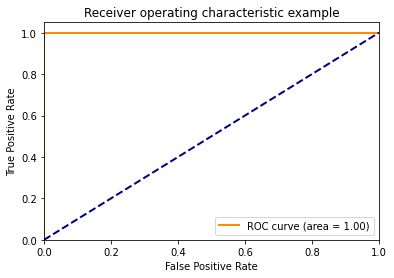

In [87]:
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(test_ground_labels.astype(np.int32), max_distances))
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [104]:
tr = [0.0056282356]
for t in tr:
    res=[]
    for d in max_distances:
        if d > t:
            res.append(1)
        else:
            res.append(0)


    print(f1_score(test_ground_labels.astype(np.int32), res))
    print(recall_score(test_ground_labels.astype(np.int32), res))
    print(precision_score(test_ground_labels.astype(np.int32), res))
    print(accuracy_score(test_ground_labels.astype(np.int32), res))
    print(confusion_matrix(test_ground_labels.astype(np.int32), res))


0.9988357081191538
1.0
0.9976741242365748
0.9998527682572369
[[935224    147]
 [     0  63055]]


In [103]:
np.mean(max_distances)

0.0056282356